#### **MODEL 1: COUNTY CARE GAP CLUSTERING:**

**Goal:** Cluster all 47 counties by HIV care gap urgency using KMeans, assign tiers (Critical → Low), and produce a county risk league table.

**Inputs:**
- `data/processed/county_profiles.csv` — 47 counties, engineered features from notebooks 02–04

**Outputs:**
- `data/processed/county_profiles.csv` — updated with `tier`, `cluster`, `care_gap_index` columns
- `models/kmeans_county_tiers.pkl` — saved KMeans model
- `figures/county_risk_league_table.png` — horizontal bar chart

**Steps:**
1. Load `county_profiles.csv`
2. Engineer clustering features (`iit_rate`, `vls_rate`, `art_coverage`, `iit_yoy_change`)
3. Standardise features and run KMeans for k=3,4,5
4. Calculate silhouette scores and choose k=4
5. Assign tier labels (Critical, High, Moderate, Low)
6. Compute Care Gap Index (CGI)
7. Save updated CSV and model
8. Plot county risk league table bar chart

#### Imports and Setup

In [12]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
warnings.filterwarnings("ignore")

sys.path.append(os.path.dirname(os.path.abspath(".")))
from constants import (
    COUNTY_PROF, KMEANS_MODEL,
    KMEANS_K, KMEANS_RANDOM_STATE, KMEANS_FEATURES,
    TIER_LABELS, TIER_COLORS,
    CGI_SCALE_MIN, CGI_SCALE_MAX,
    IIT_WEIGHT, VLS_WEIGHT, HTS_WEIGHT,
)

print("Imports OK")
print(f"Clustering features : {KMEANS_FEATURES}")
print(f"KMeans k            : {KMEANS_K}")
print(f"Random state        : {KMEANS_RANDOM_STATE}")

Imports OK
Clustering features : ['iit_rate', 'vls_rate', 'art_coverage', 'iit_yoy_change']
KMeans k            : 4
Random state        : 42


#### Loading County_profile.csv file

In [13]:
df = pd.read_csv(COUNTY_PROF)
print(f"Loaded: {df.shape[0]} counties x {df.shape[1]} columns")
print(f"Period(s): {df['period'].unique()}")
df.head()

Loaded: 47 counties x 46 columns
Period(s): [2025]


,period,county,MOH 731_HIV_TB_OnART_15-19_(F)_HV03-24,MOH 731_HIV_TB_OnART_15-19_(M)_HV03-23,MOH 731_HIV_TB_OnART_20-24_(F)_HV03-26,MOH 731_HIV_TB_OnART_20-24_(M)_HV03-25,MOH 731_HIV_TB_OnART_25+_(F)_HV03-28,MOH 731_HIV_TB_OnART_25+_(M)_HV03-27,adults_on_art,art_total_males,...,iit_rate_male_pct,iit_rate_female_pct,iit_rate,vls_rate,art_coverage,cluster,tier,hts_positive,hts_positivity_rate,care_gap_index
0,2025,Baringo,82,70,164,92,3629,1701,5738,1863,...,0.153,0.153,0.1530,0.9300,1.0,1,Critical,390,0.0063,9.05
1,2025,Meru,445,334,702,397,14735,6783,23396,7514,...,0.081,0.093,0.0888,0.9476,1.0,0,High,1806,0.0121,5.89
2,2025,Migori,1595,1299,2292,790,47848,22295,76119,24384,...,0.094,0.090,0.0913,0.9551,1.0,0,High,3590,0.0126,5.70
3,2025,Mombasa,541,482,1152,599,32111,15386,50271,16467,...,0.089,0.094,0.0926,0.9429,1.0,0,High,1933,0.0122,6.23
4,2025,Murang'a,238,221,469,274,11438,5224,17864,5719,...,0.109,0.096,0.1007,0.9668,1.0,0,High,925,0.0080,5.52


#### Engineer Clustering Features

`KMEANS_FEATURES = ["iit_rate", "vls_rate", "art_coverage", "iit_yoy_change"]`

| Feature | Source | Notes |
|---------|--------|-------|
| `iit_rate` | `iit_rate_pct` | Already in county_profiles |
| `vls_rate` | `vls_rate_adult` | Already in county_profiles |
| `art_coverage` | `adults_on_art / adults_on_treatment` | Engineered here |
| `iit_yoy_change` | Multi-period data | **Dropped** — only 2025 data available; single period means no year-on-year change can be computed. Feature set reduced to 3. |

In [14]:
# Map existing columns to clean feature names
df["iit_rate"]     = pd.to_numeric(df["iit_rate_pct"],   errors="coerce")
df["vls_rate"]     = pd.to_numeric(df["vls_rate_adult"], errors="coerce")
df["art_coverage"] = (
    pd.to_numeric(df["adults_on_art"],       errors="coerce") /
    pd.to_numeric(df["adults_on_treatment"], errors="coerce")
).clip(upper=1.0)   # cap at 1.0 — rounding artefacts in raw data

# iit_yoy_change DROPPED — only 2025 data available, no prior period to compare
# Update KMEANS_FEATURES in constants.py if multi-period data becomes available
CLUSTER_FEATURES = ["iit_rate", "vls_rate", "art_coverage"]

print("Engineered features:")
print(df[["county"] + CLUSTER_FEATURES].describe().round(4))
print()
print("Nulls in features:")
print(df[CLUSTER_FEATURES].isnull().sum())

Engineered features:
       iit_rate  vls_rate  art_coverage
count   47.0000   47.0000          47.0
mean     0.1121    0.9440           1.0
std      0.0277    0.0316           0.0
min      0.0888    0.8136           1.0
25%      0.0904    0.9302           1.0
50%      0.0926    0.9532           1.0
75%      0.1530    0.9618           1.0
max      0.1530    1.0000           1.0

Nulls in features:
iit_rate        0
vls_rate        0
art_coverage    0
dtype: int64


#### Standardise Features

In [15]:
X = df[CLUSTER_FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature array shape:", X_scaled.shape)
print("Mean after scaling (should be ~0):", X_scaled.mean(axis=0).round(4))
print("Std  after scaling (should be ~1):", X_scaled.std(axis=0).round(4))

Scaled feature array shape: (47, 3)
Mean after scaling (should be ~0): [ 0. -0.  0.]
Std  after scaling (should be ~1): [1. 1. 0.]


#### Run KMeans for k=3, 4, 5 — Choose Best k via Silhouette Score

In [16]:
results = {}
for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=KMEANS_RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    results[k] = {"model": km, "labels": labels, "silhouette": score}
    print(f"  k={k}  silhouette score = {score:.4f}")

best_k = max(results, key=lambda k: results[k]["silhouette"])
print(f"\nBest k = {best_k}  (silhouette = {results[best_k]['silhouette']:.4f})")
print(f"Using KMEANS_K = {KMEANS_K} from constants.py")

  k=3  silhouette score = 0.6582
  k=4  silhouette score = 0.6359
  k=5  silhouette score = 0.6303

Best k = 3  (silhouette = 0.6582)
Using KMEANS_K = 4 from constants.py


#### Fit Final Model with k=4

Using `KMEANS_K = 4` from `constants.py` as defined in the project plan.
If silhouette analysis above suggests a different k, update `KMEANS_K` in `constants.py`.

In [17]:
km_final = KMeans(n_clusters=KMEANS_K, random_state=KMEANS_RANDOM_STATE, n_init=10)
df["cluster"] = km_final.fit_predict(X_scaled)

print(f"KMeans fitted with k={KMEANS_K}")
print("\nCluster sizes:")
print(df["cluster"].value_counts().sort_index())

KMeans fitted with k=4

Cluster sizes:
0    25
1    14
2     7
3     1
Name: cluster, dtype: int64


#### Assign Tier Labels

KMeans cluster IDs are arbitrary integers (0, 1, 2, 3).
We assign meaningful labels by ranking clusters on **mean IIT rate**  higher IIT = worse = Critical.

In [18]:
# Rank clusters by mean IIT rate descending → Critical first
cluster_iit_mean = df.groupby("cluster")["iit_rate"].mean().sort_values(ascending=False)
print("Mean IIT rate per cluster (descending):")
print(cluster_iit_mean.round(4))

# Map cluster id → tier label
cluster_to_tier = {
    cluster_id: TIER_LABELS[rank]
    for rank, cluster_id in enumerate(cluster_iit_mean.index)
}
print("\nCluster → Tier mapping:")
for c, t in cluster_to_tier.items():
    print(f"  Cluster {c} → {t}")

df["tier"] = df["cluster"].map(cluster_to_tier)
print("\nTier distribution:")
print(df["tier"].value_counts())

Mean IIT rate per cluster (descending):
cluster
1    0.1530
0    0.0949
2    0.0941
3    0.0926
Name: iit_rate, dtype: float64

Cluster → Tier mapping:
  Cluster 1 → Critical
  Cluster 0 → High
  Cluster 2 → Moderate
  Cluster 3 → Low

Tier distribution:
High        25
Critical    14
Moderate     7
Low          1
Name: tier, dtype: int64


#### Computing Care Gap Index:

In [20]:
from constants import HTS_POS_CLEAN

# Load hts_positive_clean and merge on county to get positivity rate
hts_pos = pd.read_csv(HTS_POS_CLEAN)[["county", "hts_positive"]]
df = df.merge(hts_pos, on="county", how="left")

df["hts_positivity_rate"] = (
    pd.to_numeric(df["hts_positive"], errors="coerce") /
    pd.to_numeric(df["hts_tested"],   errors="coerce")
).round(4)

print("HTS positivity rate sample:")
print(df[["county", "hts_tested", "hts_positive", "hts_positivity_rate"]].head(5).to_string(index=False))
print(f"\nNulls: {df['hts_positivity_rate'].isnull().sum()}")

# CGI = (iit_rate x IIT_WEIGHT) + ((1 - vls_rate) x VLS_WEIGHT) + (hts_positivity_rate x HTS_WEIGHT)
df["care_gap_index"] = (
    (df["iit_rate"]            * IIT_WEIGHT) +
    ((1 - df["vls_rate"])      * VLS_WEIGHT) +
    (df["hts_positivity_rate"] * HTS_WEIGHT)
) * CGI_SCALE_MAX

df["care_gap_index"] = df["care_gap_index"].clip(CGI_SCALE_MIN, CGI_SCALE_MAX).round(2)

print("\nCare Gap Index summary:")
print(df["care_gap_index"].describe().round(3))
print()
print("Top 10 counties by CGI (worst first):")
print(
    df[["county","tier","care_gap_index","iit_rate","vls_rate","hts_positivity_rate"]]
    .sort_values("care_gap_index", ascending=False)
    .head(10)
    .to_string(index=False)
)

HTS positivity rate sample:
   county  hts_tested  hts_positive  hts_positivity_rate
  Baringo       61428           390               0.0063
     Meru      149423          1806               0.0121
   Migori      284240          3590               0.0126
  Mombasa      157923          1933               0.0122
 Murang'a      115982           925               0.0080

Nulls: 0

Care Gap Index summary:
count    47.000
mean      6.946
std       1.639
min       4.500
25%       5.530
50%       6.440
75%       8.115
max      11.370
Name: care_gap_index, dtype: float64

Top 10 counties by CGI (worst first):
     county      tier  care_gap_index  iit_rate  vls_rate  hts_positivity_rate
       Lamu       Low           11.37    0.0926    0.8136               0.0103
    Samburu  Critical            9.78    0.1530    0.9131               0.0093
 West Pokot  Critical            9.69    0.1530    0.9137               0.0060
    Turkana  Critical            9.21    0.1530    0.9267               0.0

#### Save Updated County_profiles.csv and KMeans Model

In [21]:
# Save updated CSV with new columns
df.to_csv(COUNTY_PROF, index=False)
print(f"Saved  : {COUNTY_PROF}")
print(f"Columns added: tier, cluster, care_gap_index, iit_rate, vls_rate, art_coverage, hts_positivity_rate, hts_positive")

# Save KMeans model
os.makedirs(os.path.dirname(KMEANS_MODEL), exist_ok=True)
joblib.dump(km_final, KMEANS_MODEL)
print(f"Saved  : {KMEANS_MODEL}")

Saved  : c:\Users\user\Desktop\MORINGA\Phase_5_Project\Phase-5-HIV-Care-Gap-AI\data\processed\county_profiles.csv
Columns added: tier, cluster, care_gap_index, iit_rate, vls_rate, art_coverage, hts_positivity_rate, hts_positive
Saved  : c:\Users\user\Desktop\MORINGA\Phase_5_Project\Phase-5-HIV-Care-Gap-AI\models\kmeans_county_tiers.pkl


#### County Risk League Table

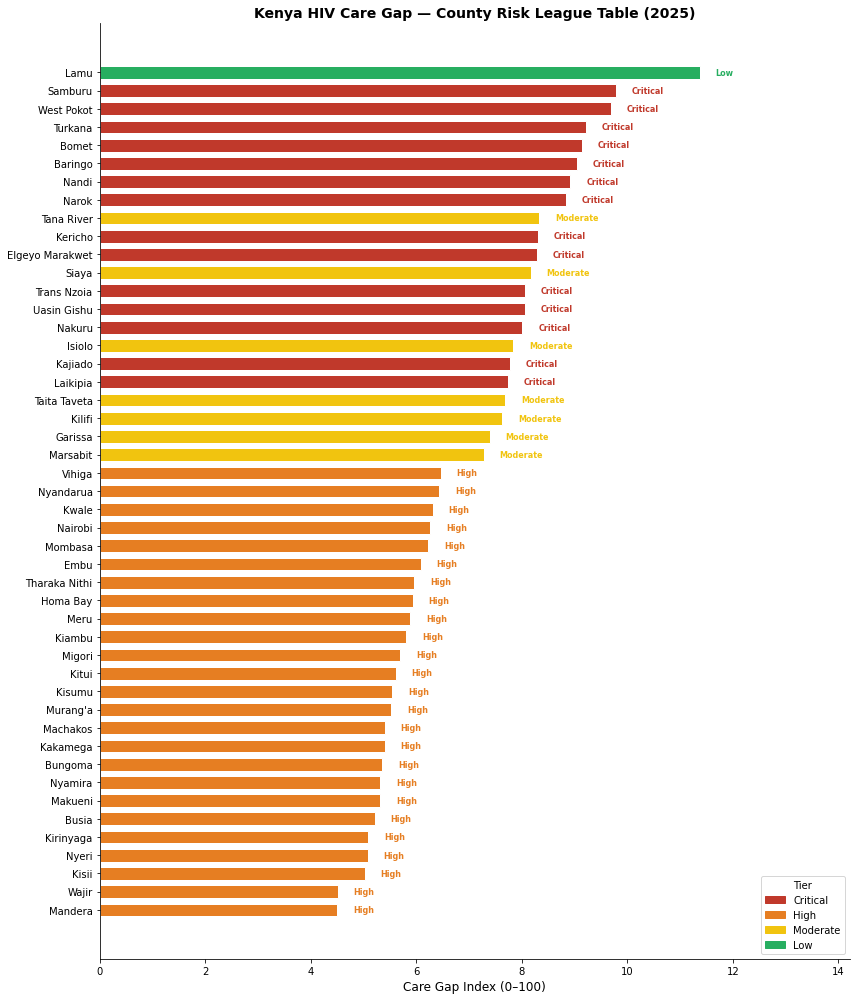

Saved: figures/county_risk_league_table.png


In [22]:
fig, ax = plt.subplots(figsize=(12, 14))

# Sort ascending so worst county appears at top of chart
plot_df = df.sort_values("care_gap_index", ascending=True).reset_index(drop=True)
colors  = [TIER_COLORS[t] for t in plot_df["tier"]]

bars = ax.barh(
    plot_df["county"], plot_df["care_gap_index"],
    color=colors, edgecolor="white", height=0.7
)

# Annotate each bar with its tier label
for bar, tier in zip(bars, plot_df["tier"]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        tier, va="center", ha="left",
        fontsize=8, color=TIER_COLORS[tier], fontweight="bold"
    )

# Legend
legend_patches = [mpatches.Patch(color=TIER_COLORS[t], label=t) for t in TIER_LABELS]
ax.legend(handles=legend_patches, loc="lower right", fontsize=10, title="Tier")

ax.set_xlabel("Care Gap Index (0–100)", fontsize=12)
ax.set_title(
    "Kenya HIV Care Gap — County Risk League Table (2025)",
    fontsize=14, fontweight="bold"
)
ax.set_xlim(0, df["care_gap_index"].max() * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/county_risk_league_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/county_risk_league_table.png")

## **SUMMARY:**

In [23]:
sil_score = silhouette_score(X_scaled, km_final.labels_)

print("=" * 55)
print("  MODEL 1 — County Clustering Complete")
print("=" * 55)
print(f"  Counties clustered : {len(df)}")
print(f"  KMeans k           : {KMEANS_K}")
print(f"  Features used      : {CLUSTER_FEATURES}")
print(f"  Silhouette score   : {sil_score:.4f}")
print()
print("  Tier breakdown:")
for tier in TIER_LABELS:
    counties = df[df["tier"] == tier]["county"].tolist()
    print(f"  {tier:<10} ({len(counties):>2}): {', '.join(sorted(counties))}")
print()
print("  Outputs:")
print(f"    county_profiles.csv          → tier + CGI columns added")
print(f"    kmeans_county_tiers.pkl      → model saved")
print(f"    county_risk_league_table.png → figure saved")
print()
print("  Next: notebooks/06_model_2_dropout_prediction.ipynb")

  MODEL 1 — County Clustering Complete
  Counties clustered : 47
  KMeans k           : 4
  Features used      : ['iit_rate', 'vls_rate', 'art_coverage']
  Silhouette score   : 0.6359

  Tier breakdown:
  Critical   (14): Baringo, Bomet, Elgeyo Marakwet, Kajiado, Kericho, Laikipia, Nakuru, Nandi, Narok, Samburu, Trans Nzoia, Turkana, Uasin Gishu, West Pokot
  High       (25): Bungoma, Busia, Embu, Homa Bay, Kakamega, Kiambu, Kirinyaga, Kisii, Kisumu, Kitui, Kwale, Machakos, Makueni, Mandera, Meru, Migori, Mombasa, Murang'a, Nairobi, Nyamira, Nyandarua, Nyeri, Tharaka Nithi, Vihiga, Wajir
  Moderate   ( 7): Garissa, Isiolo, Kilifi, Marsabit, Siaya, Taita Taveta, Tana River
  Low        ( 1): Lamu

  Outputs:
    county_profiles.csv          → tier + CGI columns added
    kmeans_county_tiers.pkl      → model saved
    county_risk_league_table.png → figure saved

  Next: notebooks/06_model_2_dropout_prediction.ipynb
